In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [4]:
df=pd.read_csv(r"C:\Users\Taizeen\Downloads\data science assignments\PCA\PCA\wine.csv")
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [5]:
print(df.shape)
print(df.info())
print(df.describe())
df.isnull().sum()

(178, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB
None
             Type     Alcohol       Malic         Ash  Alcalinity   Magnesium  \
count  178.

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

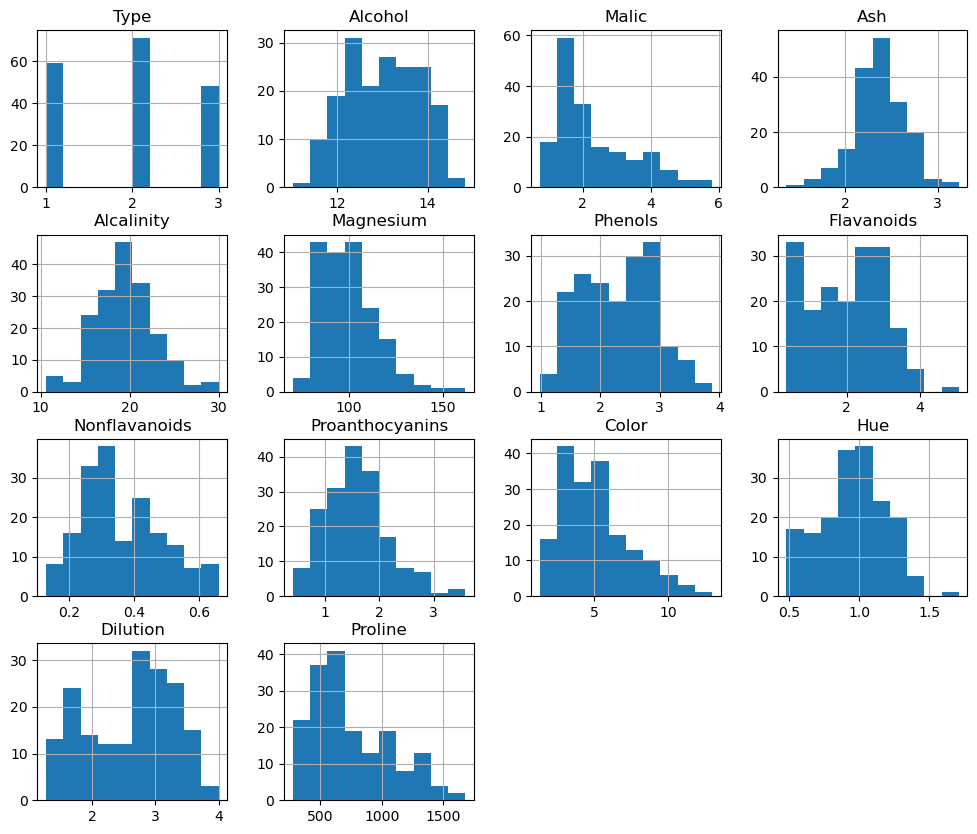

In [6]:
df.hist(figsize=(12,10))
plt.show()

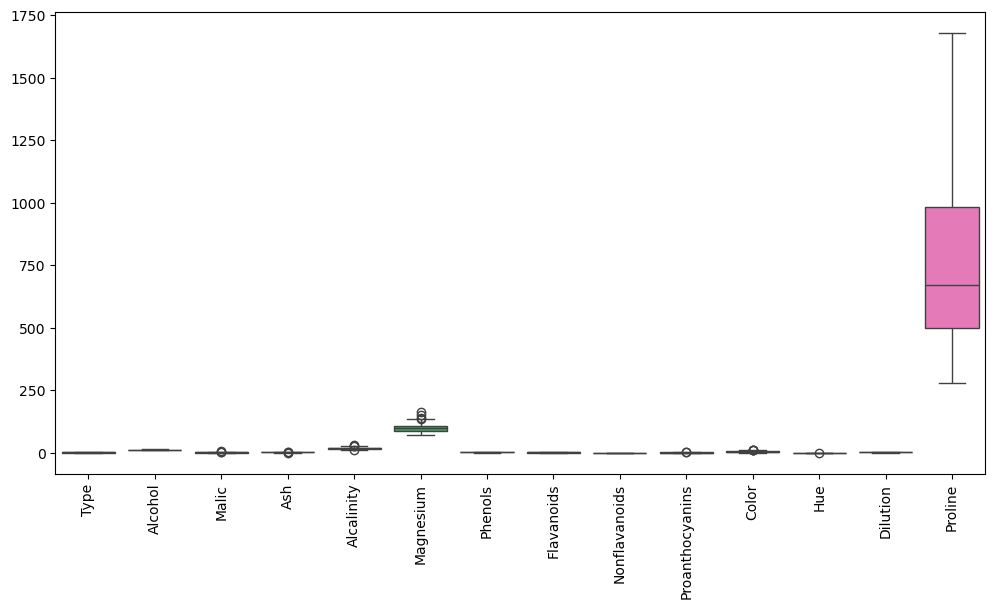

In [7]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

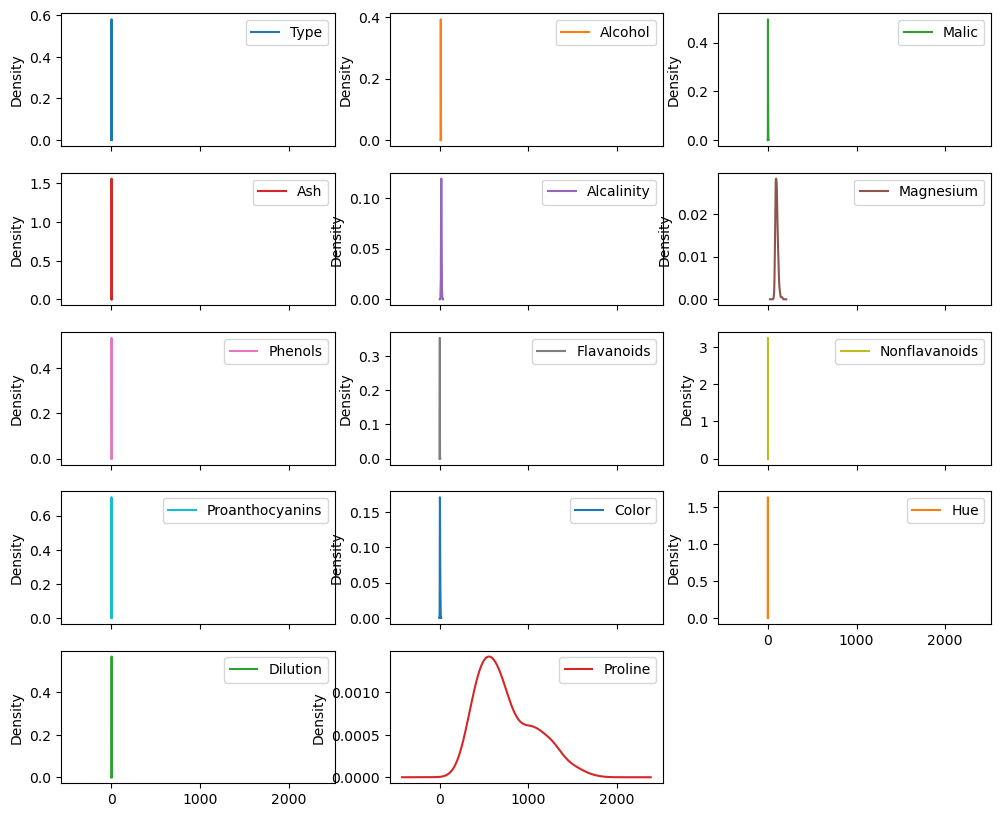

In [8]:
df.plot(kind='density',subplots=True,layout=(5,3),figsize=(12,10))
plt.show()

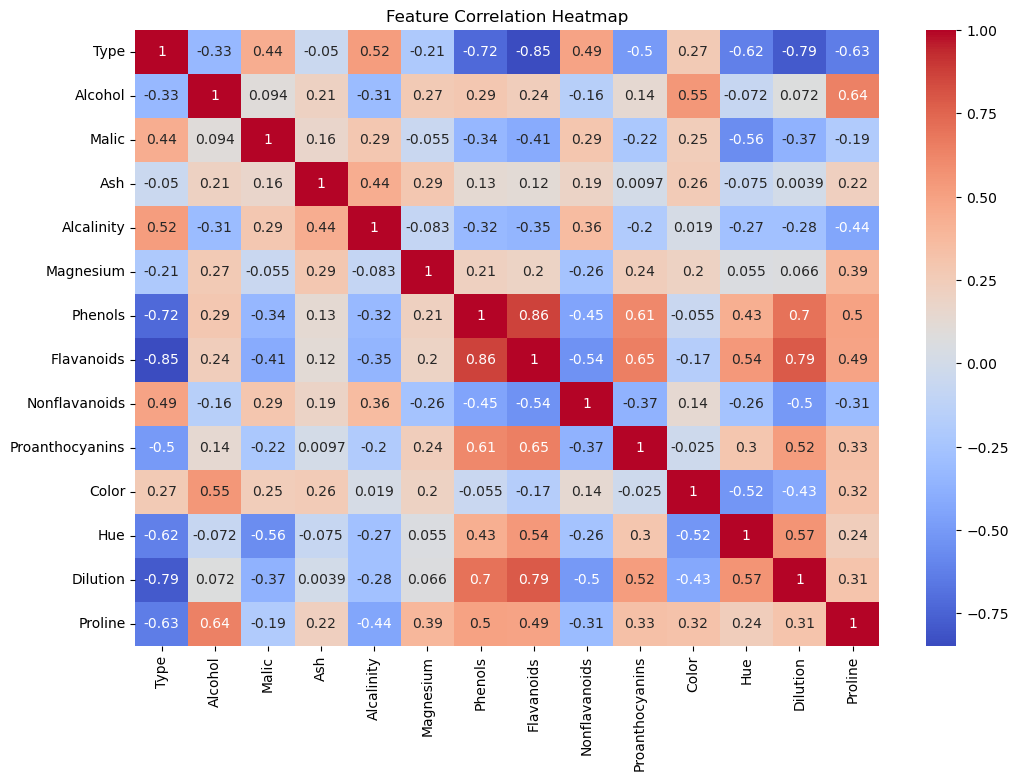

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [12]:
X=df.drop("Type",axis=1)
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [13]:
pca=PCA()
pca.fit(X_scaled)

PCA()

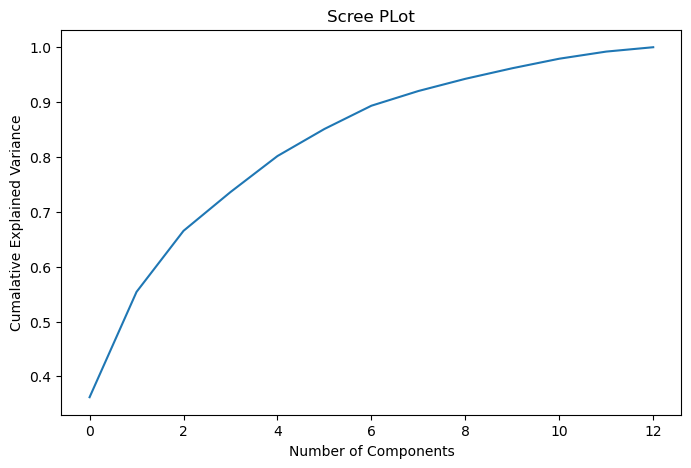

In [16]:
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumalative Explained Variance")
plt.title("Scree PLot")
plt.show()

In [20]:
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)
pca_df=pd.DataFrame(X_pca,columns=["PC1","PC2"])
pca_df.head()

,PC1,PC2
0,3.316751,1.443463
1,2.209465,-0.333393
2,2.516740,1.031151
3,3.757066,2.756372
4,1.008908,0.869831


In [22]:
kmeans_original = KMeans(n_clusters=3, random_state=42)
clusters_original = kmeans_original.fit_predict(X_scaled)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


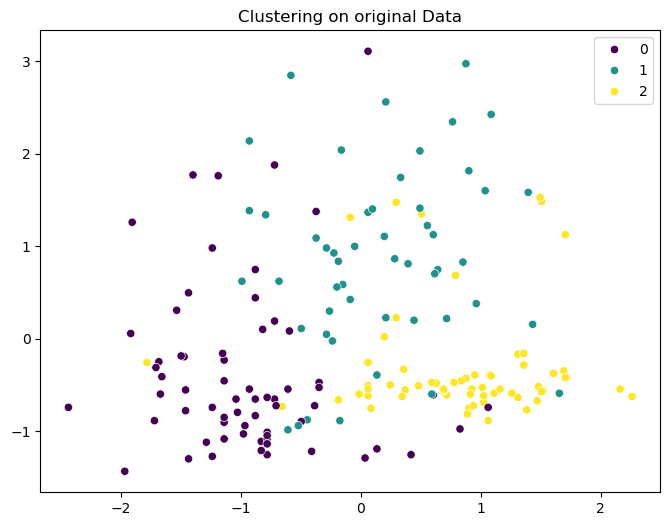

In [27]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_scaled[:,0],y=X_scaled[:,1],hue=clusters_original,palette='viridis')
plt.title("Clustering on original Data")
plt.show()

In [28]:
sil_score_orig = silhouette_score(X_scaled,clusters_original)
db_score_orig = davies_bouldin_score(X_scaled,clusters_original)

print("silhouette score:",sil_score_orig)
print("Davies bouldin Score:",db_score_orig)

silhouette score: 0.2848589191898987
Davies bouldin Score: 1.389187977718165


In [29]:
kmeans_pca = KMeans(n_clusters=3, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


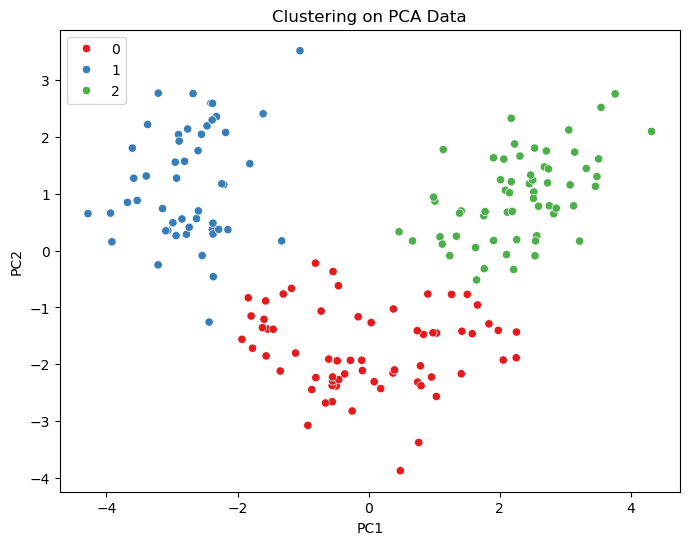

In [30]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters_pca, palette='Set1')
plt.title("Clustering on PCA Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [31]:
sil_score_pca = silhouette_score(X_pca, clusters_pca)
db_score_pca = davies_bouldin_score(X_pca, clusters_pca)

print("Silhouette Score PCA:", sil_score_pca)
print("Davies Bouldin Score PCA:", db_score_pca)

Silhouette Score PCA: 0.5601697480957203
Davies Bouldin Score PCA: 0.5977226208167407


In [32]:
comparison = pd.DataFrame({
    "Method":["Original Data","PCA Data"],
    "Silhouette Score":[sil_score_orig, sil_score_pca],
    "Davies Bouldin":[db_score_orig, db_score_pca]
})

print(comparison)

          Method  Silhouette Score  Davies Bouldin
0  Original Data          0.284859        1.389188
1       PCA Data          0.560170        0.597723


In [ ]:
Key Findings

PCA reduced the dataset from 13 features to 2 principal components.

These components captured most of the variance.

Clustering with PCA produced clearer cluster visualization.

Practical Implications

PCA helps when:

Dataset has many correlated features

Visualization is required

Computation needs to be faster